# GEOS 505: Problem Set 3

### Background:

As part of your thesis, you are using a physics-based model to predict how the timing and amount of snow water storage in the Boise River Basin will change under alternative future scenarios of climate. You have your model up and running and presented preliminary results for the first time at a recent committee meeting. One of your committee members works with the Idaho NRCS snow survey and points out that your results would be more impactful if you could present them in the context of historical observations of snow water equivalent (SWE). In particular, your committee wants you to plot your simulations on top of historical SNOTEL climatology, presented as follows: 

<img src="../img/trinity_mtn-id-wteq-por.png" alt="Trinity Mtn. SNOTEL" width="1000" style="display: block; margin: 0 auto"/>

This figure, which can be generated on the NRCS website for any SNOTEL site and many water supply basins. This particular image is the 30 year "normals" for the 1991-2020 timeframe at Trinity Mountain SNOTEL site in the Upper Boise. The plot contains a water-year oriented plot of the following items:

- The median SWE vs time,
- The median maximum annual SWE on April 1, 
- The minimum SWE vs time,
- The maximum SWE vs time, and
- Filled in ranges for SWE quintiles (bottom 20%, 20-40%, 40-60%, 60-80%, and top 20%) vs time.

### Problem: 

Your hypothetical task for your thesis and the task for this problem set is to reproduce the above figure in a way that would allow you to analyze and plot historical data at a variety of SNOTEL sites, and in a way that would allow you to plot the corresponding version of this plot with simulated data for a future climate. As such, the expected outcome of this notebook is code that produces an image that looks similar to the above. You may certainly use an alternative color scheme, but make sure that the elements of the plot are labeled.

The outline of the steps is provided below, along with some helpful suggestions of `numpy` and `matplotlib` functions that you will likely need.

### 1. Imports and Definitions

In [2]:
from datetime import datetime
from dataretrieval import nwis
from metloom.pointdata import SnotelPointData
from metloom.variables import SnotelVariables

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

startDate = '1985-10-01'
endDate = '2025-09-30'

startDate_dt = datetime.strptime(startDate, '%Y-%m-%d')
endDate_dt = datetime.strptime(endDate, '%Y-%m-%d')

# Metloom Variables
snotel_stn = '830:ID:SNTL' # Trinity Mountain Snotel Station
snotel_pnt = SnotelPointData(station_id=snotel_stn, name='TrinityMtn')

variables = [snotel_pnt.ALLOWED_VARIABLES.SWE]

### 2. Load the Data and Verify

In [3]:
df_snotel = snotel_pnt.get_daily_data(startDate_dt, endDate_dt, variables)
df_snotel


,,geometry,SWE,SWE_units,datasource
datetime,site,,,,
1985-10-01 08:00:00+00:00,830:ID:SNTL,POINT Z (-115.43818 43.62903 7790),0.0,in,NRCS
1985-10-02 08:00:00+00:00,830:ID:SNTL,POINT Z (-115.43818 43.62903 7790),0.0,in,NRCS
1985-10-03 08:00:00+00:00,830:ID:SNTL,POINT Z (-115.43818 43.62903 7790),0.0,in,NRCS
1985-10-04 08:00:00+00:00,830:ID:SNTL,POINT Z (-115.43818 43.62903 7790),0.0,in,NRCS
1985-10-05 08:00:00+00:00,830:ID:SNTL,POINT Z (-115.43818 43.62903 7790),0.0,in,NRCS
...,...,...,...,...,...
2025-09-26 08:00:00+00:00,830:ID:SNTL,POINT Z (-115.43818 43.62903 7790),0.0,in,NRCS
2025-09-27 08:00:00+00:00,830:ID:SNTL,POINT Z (-115.43818 43.62903 7790),0.0,in,NRCS
2025-09-28 08:00:00+00:00,830:ID:SNTL,POINT Z (-115.43818 43.62903 7790),0.0,in,NRCS


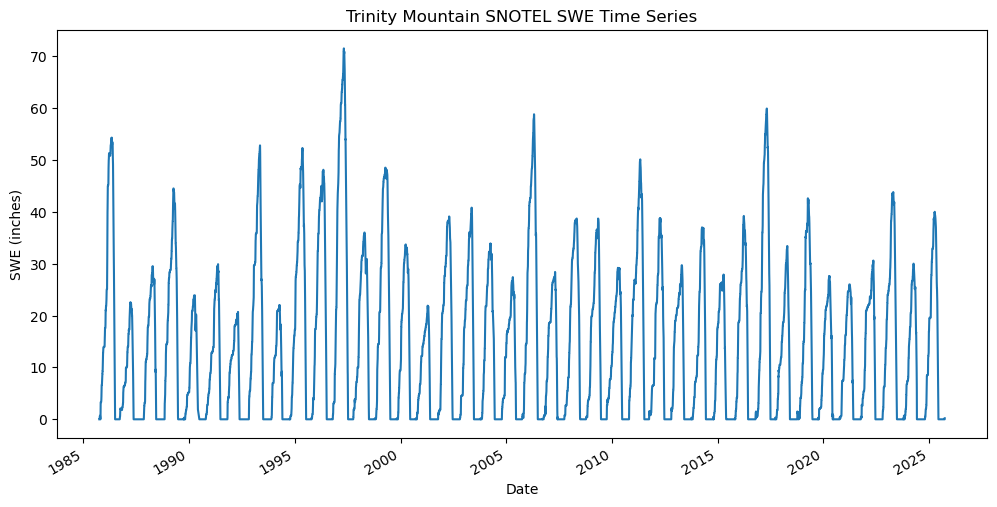

In [4]:
df_snotel.reset_index(level='site', inplace=True)
df_snotel['SWE'].plot(title='Trinity Mountain SNOTEL SWE Time Series', ylabel='SWE (inches)', xlabel='Date', figsize=(12,6))
plt.show()

In [5]:
nYears = (endDate_dt.year - startDate_dt.year) + 1



### 3. Prep Data and Preallocate Storage

In [6]:
#Convert SWE from inches to mm
df_snotel['SWE_mm'] = df_snotel['SWE'] * 25.4

# Create Water Year column
df_snotel['WaterYear'] = np.where(df_snotel.index.month >= 10,
                                  df_snotel.index.year + 1,
                                  df_snotel.index.year)

#Strip datetime of timezone info
df_snotel.index = df_snotel.index.tz_localize(None)

# Create Day of Water Year column
wy_start = pd.to_datetime((df_snotel['WaterYear'] - 1).astype(str) + '-10-01')
df_snotel['DayOfWaterYear'] = (df_snotel.index - wy_start).dt.days + 1

#Clip one off of leap years and check it
df_snotel = df_snotel[df_snotel['DayOfWaterYear']<=365]
df_snotel['DayOfWaterYear'].unique()






array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

Looks like it worked! This just clips off September 30 off leap years but for the sake of the analysis I don't think that matters too much. I had to take off the timezone because it was causing an error due to mismatched time zones between the index and the new wy_start column. Since it is daily data, the time zone isn't important, just the day.

In [10]:
#Pre-allocate 
swe_time_series = np.zeros((nYears, 365))

#Pivot the dataframe to create a 2D array
pivot_df = df_snotel.pivot(index='WaterYear', columns='DayOfWaterYear', values='SWE_mm')
pivot_df = pivot_df.reindex(columns=np.arange(1, 366))  # force all days
swe_time_series = pivot_df.to_numpy()

#Check shape
print(swe_time_series.shape)  # should be (nYears, 365)

#check array for missing values
missing_indices = np.argwhere(np.isnan(swe_time_series))
print(missing_indices)  # each row: [water_year_index, day_index]




(40, 365)
[[  4 215]
 [  4 216]
 [  4 217]
 [  4 218]
 [  4 219]
 [  4 220]
 [  4 221]
 [  4 222]
 [  4 223]
 [  4 224]
 [  4 225]
 [  4 226]
 [  4 227]
 [  4 228]
 [  4 229]
 [  4 230]
 [  4 231]
 [  4 232]
 [  4 233]
 [  4 234]
 [  4 235]
 [  4 236]
 [  4 237]
 [  4 238]
 [  4 239]
 [  4 240]
 [  4 241]
 [  4 242]
 [  4 244]
 [  4 245]
 [  4 246]
 [  4 247]
 [  4 248]
 [  4 249]
 [  4 250]
 [  4 251]
 [  4 252]
 [  4 253]
 [  4 254]
 [  4 255]
 [  4 256]
 [  4 257]
 [  4 258]
 [  4 259]
 [  4 260]
 [  4 261]
 [  4 262]
 [  4 263]
 [  4 264]
 [  4 265]
 [  4 266]]


This was tricky, but the pivot function saved me. I was trying to figure out how to create the dataframe without doing a for loop, and found the pivot function which seems to do exactly what I wanted based on the shape it creates. I also checked for missing values and found that part of the 4th year is missing. Gretchen mentioned doing an empty table of NaNs so that it wouldn't leave zeros, but it looks like even with zeros it will overwrite them with NaNs if there is missing data, which is good to know. Since there are missing values, I need to use nanmax, etc for the analysis.

### 4. Analyze Data

<Axes: >

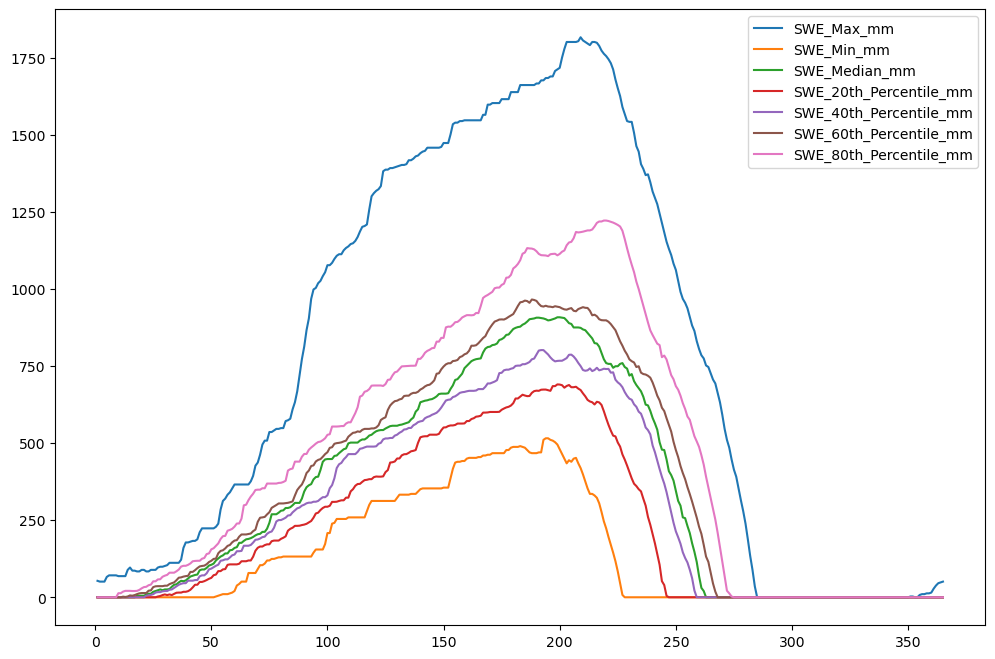

In [8]:
swe_max = np.nanmax(swe_time_series, axis=0)
swe_min = np.nanmin(swe_time_series, axis=0)
swe_median = np.nanmedian(swe_time_series, axis=0)
swe_quintiles = np.nanpercentile(swe_time_series, [20, 40, 60, 80], axis=0)
swe_stats = pd.DataFrame({
    'SWE_Max_mm': swe_max,
    'SWE_Min_mm': swe_min,
    'SWE_Median_mm': swe_median,
    'SWE_20th_Percentile_mm': swe_quintiles[0],
    'SWE_40th_Percentile_mm': swe_quintiles[1],
    'SWE_60th_Percentile_mm': swe_quintiles[2],
    'SWE_80th_Percentile_mm': swe_quintiles[3],
}, index=df_snotel['DayOfWaterYear'].unique())
swe_stats.plot(figsize=(12,8))

I calculated the necessary statistics using the NaN numpy functions and put the results in a dataframe to plot it quickly. it looks good and we don't have any missing zones. I did this without the NaN functions and the days that have the one year missing are totally blank and won't plot.

### 5. Create Plot

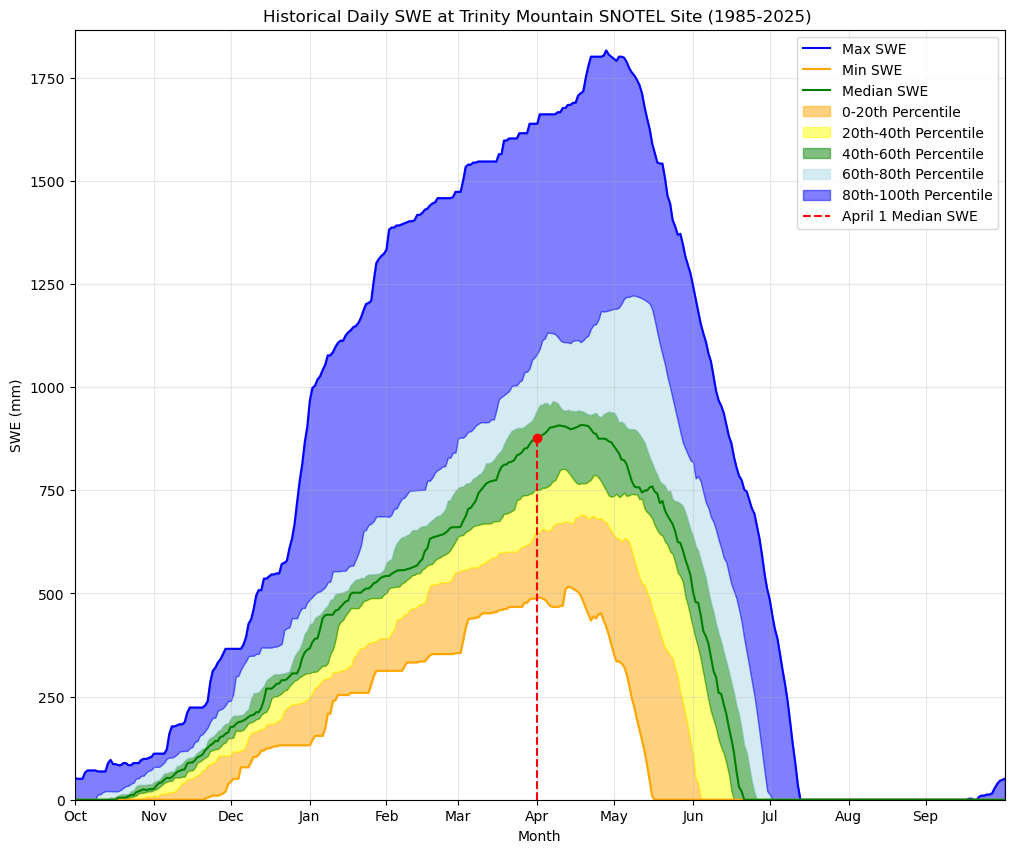

In [11]:
days = np.arange(1, 366)
fig, ax = plt.subplots(figsize=(12,10))

ax.plot(days, swe_max, label='Max SWE', color='blue')
ax.plot(days, swe_min, label='Min SWE', color='orange')
ax.plot(days, swe_median, label='Median SWE', color='green')
ax.fill_between(days, swe_min, swe_quintiles[0], color='orange', alpha=0.5, label='0-20th Percentile')
ax.fill_between(days, swe_quintiles[0], swe_quintiles[1], color='yellow', alpha=0.5, label='20th-40th Percentile')
ax.fill_between(days, swe_quintiles[1], swe_quintiles[2], color='green', alpha=0.5, label='40th-60th Percentile')
ax.fill_between(days, swe_quintiles[2], swe_quintiles[3], color='lightblue', alpha=0.5, label='60th-80th Percentile')
ax.fill_between(days, swe_quintiles[3], swe_max, color='blue', alpha=0.5, label='80th-100th Percentile')

plt.title('Historical Daily SWE at Trinity Mountain SNOTEL Site (1985-2025) ')
plt.xlabel('Month')
plt.ylabel('SWE (mm)')
plt.xlim(1, 365)
plt.ylim(0, np.nanmax(swe_max) +50)
# Set x-ticks to correspond to the first day of each month
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
month_days = [1, 32, 62, 93, 123, 151, 182, 212, 243, 273, 304, 334]
plt.xticks(month_days, month_names)
#mark median SWE april 1 with line and a marker
april_1_day = 182
plt.vlines(april_1_day, 0, np.nanmax(swe_median)-40 , colors='red', linestyles='dashed', label='April 1 Median SWE')
plt.scatter(april_1_day, swe_median[april_1_day], color='red', zorder=5)
plt.grid(alpha=0.3)




plt.legend(loc='upper right')
plt.show()

I didn't do a very creative color scheme, but the plot looks good. I created a new list of Month Names and Month Days (the day of the water year that the month starts on). I did the days with some mental math but it looks good, so I must have gotten it right. I marked the April 1 median SWE with a vertical line and a marker. I was confused about what the maximum median April 1 SWE was, so I just marked the median SWE on April 1st, which is close to the peak SWE but not quite there. I had to do some manipulation to make the plot "stick" to the edges, but other than that it was smooth sailing.